In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import proportional_hazard_test
from lifelines.utils import concordance_index
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

In [3]:
DATA_PATH = "/mnt/DataVol/Beratungen/Yurttas/survival/data"

df_A = pd.read_csv(f"{DATA_PATH}/model_A_data.csv")
df_B = pd.read_csv(f"{DATA_PATH}/model_B_data.csv")
df = pd.read_csv(f"{DATA_PATH}/reduced_data.csv")  

BASE MODEL (no PCI)


<lifelines.CoxPHFitter: fitted with 285 total observations, 154 right-censored observations>
             duration col = 'time'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 285
number of events observed = 131
   partial log-likelihood = -686.238
         time fit was run = 2026-03-24 16:09:17 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
Age         0.009     1.009     0.008          -0.006           0.025               0.994               1.025
Sex        -0.183     0.833     0.196          -0.566           0.201               0.568               1.223
Tumor_2    -0.462     0.630     0.381          -1.209           0.285               0.299               1.330
Tumor_3    -0.327     0.721     0.331          -0.976           0.322               0.377               1.380
Tumor_4    -0.747     0.474     0.305          -1.344          -0.150               0.261               0.861
Tumor_5    -1.158     0.314     0.468          -2.076          -0.240               0.125               0.787
Tumor_6     0.195     1.216     0.274          -0.341           0.732               0.711               2.079
Tumor_7    -0.532     0.587     0.468          -1.450           0.385               0.235               1.470
Tumor_8    -0.102     0.903     0.470          -1.023           0.819               0.360               2.268
Tumor_9    -1.055     0.348     1.015          -3.045           0.935               0.048               2.548
Tumor_10    0.757     2.132     1.039          -1.280           2.794               0.278              16.339
Tumor_11   -0.749     0.473     1.015          -2.739           1.241               0.065               3.461
Tumor_13   -0.280     0.756     1.022          -2.284           1.725               0.102               5.610
Tumor_15  -15.306     0.000  2243.977       -4413.420        4382.808               0.000                 inf
Tumor_16   -0.091     0.913     0.725          -1.512           1.329               0.220               3.779
Tumor_17   -0.305     0.737     1.015          -2.295           1.684               0.101               5.388
Tumor_18    0.006     1.006     1.021          -1.995           2.007               0.136               7.443
Tumor_19    1.349     3.855     1.020          -0.651           3.349               0.522              28.483

           cmp to      z     p  -log2(p)
covariate                               
Age         0.000  1.180 0.238     2.070
Sex         0.000 -0.933 0.351     1.512
Tumor_2     0.000 -1.212 0.225     2.149
Tumor_3     0.000 -0.988 0.323     1.629
Tumor_4     0.000 -2.451 0.014     6.132
Tumor_5     0.000 -2.472 0.013     6.219
Tumor_6     0.000  0.715 0.475     1.074
Tumor_7     0.000 -1.137 0.255     1.969
Tumor_8     0.000 -0.217 0.829     0.271
Tumor_9     0.000 -1.039 0.299     1.742
Tumor_10    0.000  0.729 0.466     1.101
Tumor_11    0.000 -0.737 0.461     1.117
Tumor_13    0.000 -0.273 0.785     0.350
Tumor_15    0.000 -0.007 0.995     0.008
Tumor_16    0.000 -0.126 0.900     0.152
Tumor_17    0.000 -0.301 0.764     0.389
Tumor_18    0.000  0.006 0.995     0.007
Tumor_19    0.000  1.322 0.186     2.426
---
Concordance = 0.635
Partial AIC = 1408.475
log-likelihood ratio test = 25.501 on 18 df
-log2(p) of ll-ratio test = 3.162


MODEL A — Surgical PCI


<lifelines.CoxPHFitter: fitted with 285 total observations, 154 right-censored observations>
             duration col = 'time'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 285
number of events observed = 131
   partial log-likelihood = -686.047
         time fit was run = 2026-03-24 16:09:17 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
sPCI        0.007     1.007     0.011          -0.015           0.029               0.985               1.030
Age         0.010     1.010     0.008          -0.006           0.025               0.994               1.026
Sex        -0.167     0.846     0.197          -0.554           0.220               0.575               1.246
Tumor_2    -0.438     0.645     0.383          -1.188           0.312               0.305               1.367
Tumor_3    -0.356     0.701     0.335          -1.012           0.300               0.364               1.350
Tumor_4    -0.757     0.469     0.305          -1.355          -0.159               0.258               0.853
Tumor_5    -1.226     0.293     0.481          -2.169          -0.282               0.114               0.754
Tumor_6     0.224     1.251     0.278          -0.320           0.768               0.726               2.155
Tumor_7    -0.594     0.552     0.479          -1.533           0.344               0.216               1.410
Tumor_8    -0.068     0.934     0.473          -0.995           0.859               0.370               2.361
Tumor_9    -1.115     0.328     1.020          -3.115           0.884               0.044               2.422
Tumor_10    0.781     2.184     1.040          -1.257           2.819               0.285              16.759
Tumor_11   -0.735     0.480     1.016          -2.725           1.256               0.066               3.510
Tumor_13   -0.325     0.723     1.025          -2.333           1.684               0.097               5.388
Tumor_15  -15.370     0.000  2245.105       -4415.696        4384.956               0.000                 inf
Tumor_16   -0.113     0.894     0.725          -1.534           1.309               0.216               3.704
Tumor_17   -0.383     0.682     1.023          -2.388           1.622               0.092               5.064
Tumor_18   -0.025     0.976     1.022          -2.027           1.978               0.132               7.230
Tumor_19    1.323     3.755     1.021          -0.678           3.325               0.507              27.793

           cmp to      z     p  -log2(p)
covariate                               
sPCI        0.000  0.620 0.536     0.901
Age         0.000  1.253 0.210     2.251
Sex         0.000 -0.847 0.397     1.333
Tumor_2     0.000 -1.144 0.253     1.985
Tumor_3     0.000 -1.063 0.288     1.798
Tumor_4     0.000 -2.479 0.013     6.247
Tumor_5     0.000 -2.547 0.011     6.523
Tumor_6     0.000  0.806 0.420     1.250
Tumor_7     0.000 -1.242 0.214     2.222
Tumor_8     0.000 -0.144 0.886     0.175
Tumor_9     0.000 -1.093 0.274     1.866
Tumor_10    0.000  0.751 0.452     1.144
Tumor_11    0.000 -0.724 0.469     1.091
Tumor_13    0.000 -0.317 0.751     0.412
Tumor_15    0.000 -0.007 0.995     0.008
Tumor_16    0.000 -0.155 0.877     0.190
Tumor_17    0.000 -0.374 0.708     0.498
Tumor_18    0.000 -0.024 0.981     0.028
Tumor_19    0.000  1.296 0.195     2.358
---
Concordance = 0.638
Partial AIC = 1410.094
log-likelihood ratio test = 25.882 on 19 df
-log2(p) of ll-ratio test = 2.905


MODEL B — Pathological PCI


<lifelines.CoxPHFitter: fitted with 285 total observations, 154 right-censored observations>
             duration col = 'time'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 285
number of events observed = 131
   partial log-likelihood = -685.750
         time fit was run = 2026-03-24 16:09:18 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
pPCI        0.017     1.017     0.017          -0.016           0.050               0.984               1.051
Age         0.010     1.010     0.008          -0.005           0.026               0.995               1.026
Sex        -0.154     0.857     0.198          -0.542           0.234               0.582               1.264
Tumor_2    -0.423     0.655     0.383          -1.174           0.328               0.309               1.388
Tumor_3    -0.351     0.704     0.332          -1.002           0.300               0.367               1.350
Tumor_4    -0.762     0.467     0.305          -1.361          -0.164               0.256               0.849
Tumor_5    -1.207     0.299     0.472          -2.132          -0.283               0.119               0.754
Tumor_6     0.257     1.293     0.281          -0.294           0.808               0.745               2.244
Tumor_7    -0.553     0.575     0.469          -1.472           0.365               0.230               1.441
Tumor_8    -0.063     0.939     0.471          -0.986           0.861               0.373               2.365
Tumor_9    -1.062     0.346     1.016          -3.052           0.929               0.047               2.532
Tumor_10    0.861     2.366     1.045          -1.187           2.909               0.305              18.338
Tumor_11   -0.726     0.484     1.016          -2.717           1.264               0.066               3.540
Tumor_13   -0.354     0.702     1.025          -2.364           1.656               0.094               5.237
Tumor_15  -15.366     0.000  2246.944       -4419.296        4388.564               0.000                 inf
Tumor_16   -0.126     0.881     0.726          -1.548           1.296               0.213               3.654
Tumor_17   -0.419     0.658     1.021          -2.421           1.583               0.089               4.868
Tumor_18   -0.096     0.908     1.026          -2.106           1.914               0.122               6.781
Tumor_19    1.223     3.396     1.028          -0.792           3.237               0.453              25.469

           cmp to      z     p  -log2(p)
covariate                               
pPCI        0.000  0.992 0.321     1.638
Age         0.000  1.292 0.196     2.349
Sex         0.000 -0.778 0.436     1.196
Tumor_2     0.000 -1.104 0.270     1.892
Tumor_3     0.000 -1.055 0.291     1.780
Tumor_4     0.000 -2.496 0.013     6.315
Tumor_5     0.000 -2.560 0.010     6.577
Tumor_6     0.000  0.914 0.361     1.471
Tumor_7     0.000 -1.181 0.238     2.073
Tumor_8     0.000 -0.133 0.894     0.162
Tumor_9     0.000 -1.045 0.296     1.757
Tumor_10    0.000  0.824 0.410     1.287
Tumor_11    0.000 -0.715 0.474     1.076
Tumor_13    0.000 -0.345 0.730     0.454
Tumor_15    0.000 -0.007 0.995     0.008
Tumor_16    0.000 -0.174 0.862     0.215
Tumor_17    0.000 -0.410 0.681     0.553
Tumor_18    0.000 -0.094 0.925     0.112
Tumor_19    0.000  1.189 0.234     2.094
---
Concordance = 0.641
Partial AIC = 1409.500
log-likelihood ratio test = 26.476 on 19 df
-log2(p) of ll-ratio test = 3.090


── C-index Comparison ──────────────────────────────────
  Base model (no PCI): 0.6350
  Model A (sPCI):      0.6382  | Δ vs base: +0.0033
  Model B (pPCI):      0.6409  | Δ vs base: +0.0059

── AIC Comparison ──────────────────────────────────────
  Base model: 1408.48
  Model A:    1410.09  | ΔAIC vs base: +1.62
  Model B:    1409.50  | ΔAIC vs base: +1.02

── Likelihood Ratio Test vs Base ───────────────────────
  Model A (sPCI): χ²=0.381, p=0.5368
  Model B (pPCI): χ²=0.975, p=0.3234

── PH Assumption — Model A ─────────────────────────────



── PH Assumption — Model B ─────────────────────────────


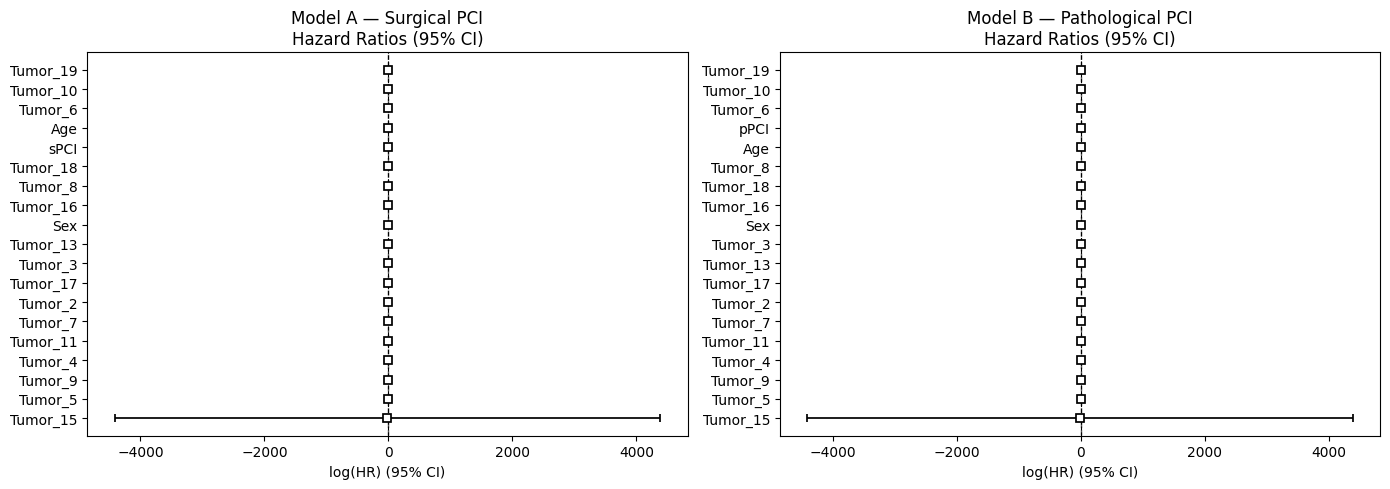


── Final Comparison Summary ────────────────────────────
Metric                               Base    Model A    Model B
--------------------------------------------------------------
C-index                            0.6350     0.6382     0.6409
AIC                               1408.48    1410.09    1409.50
LRT p-value vs base                     —     0.5368     0.3234
PCI HR p-value                          —     0.5355     0.3212


In [7]:
import pandas as pd
import numpy as np
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
from lifelines.utils import concordance_index
import matplotlib.pyplot as plt

cph_base = CoxPHFitter()
cph_A    = CoxPHFitter()
cph_B    = CoxPHFitter()

tumor_cols  = [c for c in df.columns if c.startswith("Tumor_")]
base_covars = ["Age", "Sex"] + tumor_cols

# ── 1. Fit all three models ───────────────────────────────────────────────────
cph_base.fit(df[base_covars + ["time", "status"]],
             duration_col="time", event_col="status")

cph_A.fit(df[["sPCI"] + base_covars + ["time", "status"]],
          duration_col="time", event_col="status")

cph_B.fit(df[["pPCI"] + base_covars + ["time", "status"]],
          duration_col="time", event_col="status")

# ── 2. Print summaries ────────────────────────────────────────────────────────
print("=" * 60)
print("BASE MODEL (no PCI)")
print("=" * 60)
cph_base.print_summary(decimals=3)

print("\n" + "=" * 60)
print("MODEL A — Surgical PCI")
print("=" * 60)
cph_A.print_summary(decimals=3)

print("\n" + "=" * 60)
print("MODEL B — Pathological PCI")
print("=" * 60)
cph_B.print_summary(decimals=3)

# ── 3. C-index comparison ─────────────────────────────────────────────────────
df_base = df[base_covars + ["time", "status"]].dropna()
df_A    = df[["sPCI"] + base_covars + ["time", "status"]].dropna()
df_B    = df[["pPCI"] + base_covars + ["time", "status"]].dropna()

c_base = concordance_index(df_base["time"],
                           -cph_base.predict_partial_hazard(df_base),
                           df_base["status"])
c_A    = concordance_index(df_A["time"],
                           -cph_A.predict_partial_hazard(df_A),
                           df_A["status"])
c_B    = concordance_index(df_B["time"],
                           -cph_B.predict_partial_hazard(df_B),
                           df_B["status"])

print("\n── C-index Comparison ──────────────────────────────────")
print(f"  Base model (no PCI): {c_base:.4f}")
print(f"  Model A (sPCI):      {c_A:.4f}  | Δ vs base: {c_A - c_base:+.4f}")
print(f"  Model B (pPCI):      {c_B:.4f}  | Δ vs base: {c_B - c_base:+.4f}")

# ── 4. AIC comparison ─────────────────────────────────────────────────────────
def aic(fitted_model, n_params):
    return -2 * fitted_model.log_likelihood_ + 2 * n_params

n_base = len(base_covars)
aic_base = aic(cph_base, n_base)
aic_A    = aic(cph_A,    n_base + 1)
aic_B    = aic(cph_B,    n_base + 1)

print("\n── AIC Comparison ──────────────────────────────────────")
print(f"  Base model: {aic_base:.2f}")
print(f"  Model A:    {aic_A:.2f}  | ΔAIC vs base: {aic_A - aic_base:+.2f}")
print(f"  Model B:    {aic_B:.2f}  | ΔAIC vs base: {aic_B - aic_base:+.2f}")

# ── 5. Likelihood ratio test vs base ─────────────────────────────────────────
from scipy.stats import chi2

def lrt(base_ll, full_ll, df_diff=1):
    stat = 2 * (full_ll - base_ll)
    p    = chi2.sf(stat, df_diff)
    return stat, p

ll_base = cph_base.log_likelihood_
ll_A    = cph_A.log_likelihood_
ll_B    = cph_B.log_likelihood_

stat_A, p_A = lrt(ll_base, ll_A)
stat_B, p_B = lrt(ll_base, ll_B)

print("\n── Likelihood Ratio Test vs Base ───────────────────────")
print(f"  Model A (sPCI): χ²={stat_A:.3f}, p={p_A:.4f}")
print(f"  Model B (pPCI): χ²={stat_B:.3f}, p={p_B:.4f}")

# ── 6. Proportional hazards assumption ───────────────────────────────────────
print("\n── PH Assumption — Model A ─────────────────────────────")
proportional_hazard_test(cph_A, df_A, time_transform="rank").print_summary(decimals=3)

print("\n── PH Assumption — Model B ─────────────────────────────")
proportional_hazard_test(cph_B, df_B, time_transform="rank").print_summary(decimals=3)

# ── 7. Forest plots ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cph_A.plot(ax=axes[0])
axes[0].set_title("Model A — Surgical PCI\nHazard Ratios (95% CI)")
axes[0].axvline(0, color="black", linestyle="--", linewidth=0.8)

cph_B.plot(ax=axes[1])
axes[1].set_title("Model B — Pathological PCI\nHazard Ratios (95% CI)")
axes[1].axvline(0, color="black", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()

# ── 8. Summary comparison table ──────────────────────────────────────────────
print("\n── Final Comparison Summary ────────────────────────────")
print(f"{'Metric':<30} {'Base':>10} {'Model A':>10} {'Model B':>10}")
print("-" * 62)
print(f"{'C-index':<30} {c_base:>10.4f} {c_A:>10.4f} {c_B:>10.4f}")
print(f"{'AIC':<30} {aic_base:>10.2f} {aic_A:>10.2f} {aic_B:>10.2f}")
print(f"{'LRT p-value vs base':<30} {'—':>10} {p_A:>10.4f} {p_B:>10.4f}")
print(f"{'PCI HR p-value':<30} {'—':>10}", end="")
print(f" {cph_A.summary.loc['sPCI', 'p']:>10.4f}", end="")
print(f" {cph_B.summary.loc['pPCI', 'p']:>10.4f}")

In [9]:
# 1. Check what IS significant in the base model
print(cph_base.summary[["exp(coef)", "exp(coef) lower 95%",
                          "exp(coef) upper 95%", "p"]].round(3))

           exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%      p
covariate                                                            
Age            1.009                0.994                1.025  0.238
Sex            0.833                0.568                1.223  0.351
Tumor_2        0.630                0.299                1.330  0.225
Tumor_3        0.721                0.377                1.380  0.323
Tumor_4        0.474                0.261                0.861  0.014
Tumor_5        0.314                0.125                0.787  0.013
Tumor_6        1.216                0.711                2.079  0.475
Tumor_7        0.587                0.235                1.470  0.255
Tumor_8        0.903                0.360                2.268  0.829
Tumor_9        0.348                0.048                2.548  0.299
Tumor_10       2.132                0.278               16.339  0.466
Tumor_11       0.473                0.065                3.461  0.461
Tumor_13       0.756

In [10]:
# 2. Test PCI as binary (0 vs >0) — captures zero-inflation effect
df["sPCI_bin"] = (df["sPCI"] > 0).astype(int)
df["pPCI_bin"] = (df["pPCI"] > 0).astype(int)

cph_Abin = CoxPHFitter()
cph_Bbin = CoxPHFitter()

cph_Abin.fit(df[["sPCI_bin"] + base_covars + ["time", "status"]],
             duration_col="time", event_col="status")
cph_Bbin.fit(df[["pPCI_bin"] + base_covars + ["time", "status"]],
             duration_col="time", event_col="status")

print("\nBinary sPCI HR:", cph_Abin.summary.loc["sPCI_bin", ["exp(coef)", "p"]])
print("Binary pPCI HR:", cph_Bbin.summary.loc["pPCI_bin", ["exp(coef)", "p"]])

/home/luisggon/.cache/pypoetry/virtualenvs/survival-IXeM1eyz-py3.12/lib/python3.12/site-packages/lifelines/utils/__init__.py:797: RuntimeWarning: invalid value encountered in divide
  return (X - mean) / std
/home/luisggon/.cache/pypoetry/virtualenvs/survival-IXeM1eyz-py3.12/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1530: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 0.0.
  inv_h_dot_g_T = spsolve(-h, g, assume_a="pos", check_finite=False)


ConvergenceError: delta contains nan value(s). Convergence halted. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model

In [11]:
# 3. Test a clinical cutoff (e.g. PCI > 20 = extensive disease)
df["sPCI_high"] = (df["sPCI"] > 20).astype(int)
df["pPCI_high"] = (df["pPCI"] > 20).astype(int)

cph_Ahigh = CoxPHFitter()
cph_Bhigh = CoxPHFitter()

cph_Ahigh.fit(df[["sPCI_high"] + base_covars + ["time", "status"]],
              duration_col="time", event_col="status")
cph_Bhigh.fit(df[["pPCI_high"] + base_covars + ["time", "status"]],
              duration_col="time", event_col="status")

print("\nHigh sPCI HR:", cph_Ahigh.summary.loc["sPCI_high", ["exp(coef)", "p"]])
print("High pPCI HR:", cph_Bhigh.summary.loc["pPCI_high", ["exp(coef)", "p"]])


High sPCI HR: exp(coef)    1.473736
p            0.065727
Name: sPCI_high, dtype: float64
High pPCI HR: exp(coef)    1.847527
p            0.107855
Name: pPCI_high, dtype: float64
